In [355]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import pybaseball as pb

In [356]:
# data = pd.read_csv('statcast_2023_2025.csv')

In [357]:
# df = data.loc[data.description == 'hit_into_play']
df = data.loc[((data.bb_type.isin(['fly_ball', 'line_drive', 'popup'])))]

In [358]:
df = df[['hc_x','hc_y','events','launch_speed','launch_angle','if_fielding_alignment','of_fielding_alignment','stand','des','bb_type']]

In [359]:
df = df.loc[df.events != 'catch_interf']
df = df.loc[~df.des.str.contains('in foul territory')]
df = df.dropna()

In [360]:
multi_out = df["events"].isin([
    "double_play",
    "triple_play"
])

caught_multi_out = (
    multi_out
    & df["des"].str.contains(
        r"\b(?:lines|flies|pops) into\b",
        case=False,
        regex=True,
        na=False
    )
)

df.loc[caught_multi_out, "caught"] = 1
df.loc[multi_out & ~caught_multi_out, "caught"] = 0

import numpy as np

caught_events = {
    "field_out",
    "sac_fly",
    "sac_fly_double_play"
}

not_caught_events = {
    "single",
    "double",
    "triple",
    "home_run",
    "field_error",
    "force_out",
    "fielders_choice",
    "fielders_choice_out",
    "grounded_into_double_play"
}

df["caught"] = np.nan

df.loc[df["events"].isin(caught_events), "caught"] = 1
df.loc[df["events"].isin(not_caught_events), "caught"] = 0

multi_out = df["events"].isin(["double_play", "triple_play"])

caught_multi_out = (
    multi_out
    & df["des"].str.contains(
        r"\b(?:lines|flies|pops) into\b",
        case=False,
        regex=True,
        na=False
    )
)

df.loc[caught_multi_out, "caught"] = 1
df.loc[multi_out & ~caught_multi_out, "caught"] = 0

In [361]:
if_map = {'Infield shade':2, 'Standard':0, 'Strategic':1}
of_map = {'Standard':0, 'Strategic':1}
bb_map = {'fly_ball':0, 'line_drive':1, 'popup':2}
df['if_fielding_alignment'] = df['if_fielding_alignment'].map(if_map)
df['of_fielding_alignment'] = df['of_fielding_alignment'].map(of_map)
df['stand'] = df['stand'].map({'L':0, 'R':1})
df['bb_type'] = df['bb_type'].map(bb_map)

In [362]:
features = ['hc_x','hc_y','launch_speed','launch_angle','if_fielding_alignment','of_fielding_alignment','stand']

In [363]:
df = df.dropna()

# XGBOOST

In [364]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[features]
y = df["caught"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [365]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)
preds = xgb_model.predict(X_test)
accuracy_score(preds, y_test)
print(classification_report(y_pred=preds, y_true=y_test))

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.90     16334
         1.0       0.92      0.94      0.93     24210

    accuracy                           0.92     40544
   macro avg       0.92      0.91      0.91     40544
weighted avg       0.92      0.92      0.92     40544



# Binary Logistic

In [366]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

preds = lr_model.predict(X_test)
accuracy_score(preds, y_test)
print(classification_report(y_pred=preds, y_true=y_test))

              precision    recall  f1-score   support

         0.0       0.65      0.71      0.68     16334
         1.0       0.79      0.75      0.77     24210

    accuracy                           0.73     40544
   macro avg       0.72      0.73      0.72     40544
weighted avg       0.74      0.73      0.73     40544



In [367]:
from sklearn.ensemble import (
    RandomForestClassifier
)

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

preds = rf_model.predict(X_test)
accuracy_score(preds, y_test)
print(classification_report(y_pred=preds, y_true=y_test))

              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89     16334
         1.0       0.92      0.93      0.93     24210

    accuracy                           0.91     40544
   macro avg       0.91      0.91      0.91     40544
weighted avg       0.91      0.91      0.91     40544



In [368]:
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

et_model = ExtraTreesClassifier()

et_model.fit(X_train, y_train)

preds = et_model.predict(X_test)
accuracy_score(preds, y_test)
print(classification_report(y_pred=preds, y_true=y_test))

              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89     16334
         1.0       0.92      0.93      0.93     24210

    accuracy                           0.91     40544
   macro avg       0.91      0.90      0.91     40544
weighted avg       0.91      0.91      0.91     40544



# XGBOOST

In [369]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)
preds = xgb_model.predict(X_test)
accuracy_score(preds, y_test)
print(classification_report(y_pred=preds, y_true=y_test))

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.90     16334
         1.0       0.92      0.94      0.93     24210

    accuracy                           0.92     40544
   macro avg       0.92      0.91      0.91     40544
weighted avg       0.92      0.92      0.92     40544



In [370]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score
)

probabilities = xgb_model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, probabilities))
print("Log loss:", log_loss(y_test, probabilities))
print("Brier score:", brier_score_loss(y_test, probabilities))

ROC AUC: 0.9717200881009992
Log loss: 0.2045209485962127
Brier score: 0.06092131731281246


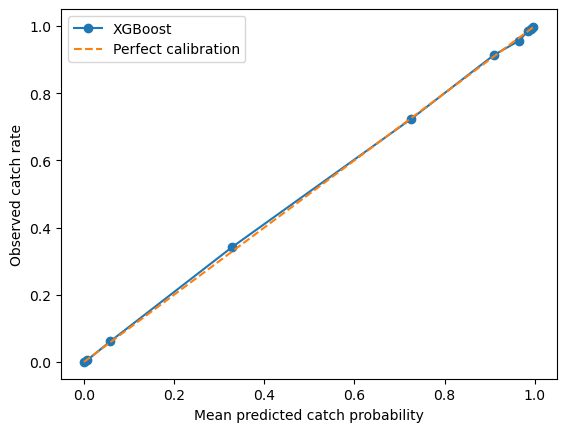

In [371]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

observed, predicted = calibration_curve(
    y_test,
    probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.plot(predicted, observed, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted catch probability")
plt.ylabel("Observed catch rate")
plt.legend()
plt.show()